In [1]:
#LOAD DATA AND PREPROCESSING
import pandas as pd
import numpy as np
import ast

# === STEP 1: LOAD & RENAME ===
data_path = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/20251023-s288c-annotated-PPI-net.pkl"
df = pd.read_pickle(data_path)

# === STEP 2: SUBSET AND CLEAN ===
selected_columns = df[[
    'node', '_wkshell', 'Y2H_wkshell',
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality', 'closeness_centrality',
    'load_centrality', 'pagerank', 'information_centrality',
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality',
    'DeepTMHMM_class', 'signalP_trimmed_sequence',
    'IDR_count', 'N_aa_disordered', 'disorder_fraction',
    'is_disordered_0.05', 'is_disordered_0.10', 'is_disordered_0.15', 'is_disordered_0.20', 'is_disordered_0.25', 'is_disordered_0.30', 'is_disordered_0.35', 
    'is_disordered_0.40', 'is_disordered_0.45', 'is_disordered_0.50', 'is_disordered_0.55', 'is_disordered_0.60', 'is_disordered_0.65', 'is_disordered_0.70', 
    'is_disordered_0.75', 'is_disordered_0.80', 'is_disordered_0.85', 'is_disordered_0.90', 'is_disordered_0.95', 'is_disordered_1.00',
    'mean_plddt', 'L', 
    'Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score', 'FoldX_best_total_energy',
    'Christiano_degradation_rate(min-1)', 'Villen_halflife_min',
    'mean_molecules_per_cell', 'median_molecules_per_cell', 'log2_TE',
    'interacting_chaperones', 'in_complex', 'Pfam_Ndomains', 
    'essential',  
    'sequence', 'structure_exists', 'sequence_matches_structure', 'meltome-melting-point'
       
]].copy()

# Multiply 'cagiada-dG' by -1 (flip sign)
selected_columns['cagiada-dG'] = pd.to_numeric(selected_columns['cagiada-dG'], errors='coerce') * -1

# Replace infinite values with NaN to allow proper cleaning
selected_columns.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fix Pfam_Ndomains: replace empty/NaN with 0
selected_columns['Pfam_Ndomains'] = selected_columns['Pfam_Ndomains'].fillna(0).astype(int)

# === STEP 3: DERIVED FEATURES ===
selected_columns['Length'] = selected_columns['signalP_trimmed_sequence'].fillna('').apply(len)

# Add percentile columns for all centrality metrics
ms_centrality_cols = [
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality',
    'closeness_centrality', 'load_centrality', 'pagerank', 'information_centrality'
]
y2h_centrality_cols = [
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality'
]

# Rename MS columns
ms_rename_map = {col: "MS_" + col for col in ms_centrality_cols}
selected_columns.rename(columns=ms_rename_map, inplace=True)

# Add percentiles for MS-based metrics
for col in ms_centrality_cols:
    ms_col = "MS_" + col
    selected_columns[f"{ms_col}_percentile"] = selected_columns[ms_col].rank(pct=True) * 100

# Add percentiles for Y2H-based metrics
for col in y2h_centrality_cols:
    selected_columns[f"{col}_percentile"] = selected_columns[col].rank(pct=True) * 100

# === STEP 4: ONE HOT ENCODING FOR CHAPERONES ===
def fix_list(val):
    if isinstance(val, list):
        return val
    elif isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    elif pd.isnull(val):
        return []
    else:
        return []

selected_columns['interacting_chaperones'] = selected_columns['interacting_chaperones'].apply(fix_list)

def chaperone_category(row):
    node = row['node']
    chaps = row['interacting_chaperones']
    if not chaps or chaps == []:
        return 'protein_is_neither_chaperone_nor_interacts'
    elif node in chaps:
        return 'protein_is_chaperone'
    else:
        return 'protein_interacts_with_chaperone'

selected_columns['chaperone_category'] = selected_columns.apply(chaperone_category, axis=1)
selected_columns['is_chaperone'] = (selected_columns['chaperone_category'] == 'protein_is_chaperone').astype(int)
selected_columns['interacts_with_chaperone'] = (selected_columns['chaperone_category'] == 'protein_interacts_with_chaperone').astype(int)
selected_columns['neither_chaperone_nor_interacts'] = (selected_columns['chaperone_category'] == 'protein_is_neither_chpaerone_nor_interacts').astype(int)

# === STEP 5: Match seq and structure nodes ===
selected_columns.info()
selected_columns = selected_columns[~selected_columns["sequence"].isna()]
print (f"Number of nodes with sequence information: {selected_columns.shape[0]}")

# record those nodes that do not have sequence information
no_seq_nodes = selected_columns[selected_columns["sequence"].isna()]
print (f"Number of nodes without sequence information: {no_seq_nodes.shape[0]}")

# remove nodes with no structure from AF2
selected_columns = selected_columns[selected_columns["structure_exists"] == 1]
print (f"Number of nodes with sequence & structure information: {selected_columns.shape[0]}")

# a small number of nodes have an AF2 structure, but its sequence does not match the sequence information from SGD - we can filter those out as well
selected_columns = selected_columns[selected_columns["sequence_matches_structure"] == True]
print (f"Number of nodes with sequence, structure, and matching information between the two: {selected_columns.shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3927 entries, 0 to 3926
Data columns (total 80 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   node                                   3927 non-null   object 
 1   _wkshell                               3927 non-null   int64  
 2   Y2H_wkshell                            1465 non-null   float64
 3   MS_degree_centrality                   3927 non-null   float64
 4   MS_betweenness_centrality              3927 non-null   float64
 5   MS_eigenvector_centrality              3927 non-null   float64
 6   MS_closeness_centrality                3927 non-null   float64
 7   MS_load_centrality                     3927 non-null   float64
 8   MS_pagerank                            3927 non-null   float64
 9   MS_information_centrality              3927 non-null   float64
 10  Y2H_degree_centrality                  1465 non-null   float64
 11  Y2H_

1C-a - MS Degree Centrality vs Y2H Degree Centrality: Pearson r = -0.04 (p=1.13e-01), Spearman ρ = -0.04 (p=1.24e-01)
1C-a - MS Degree Centrality vs Y2H Degree Centrality: R² (linear fit) = 0.00
1C-b - MS Betweenness Centrality vs Y2H Betweenness Centrality: Pearson r = 0.03 (p=2.71e-01), Spearman ρ = 0.03 (p=2.49e-01)
1C-b - MS Betweenness Centrality vs Y2H Betweenness Centrality: R² (linear fit) = 0.00


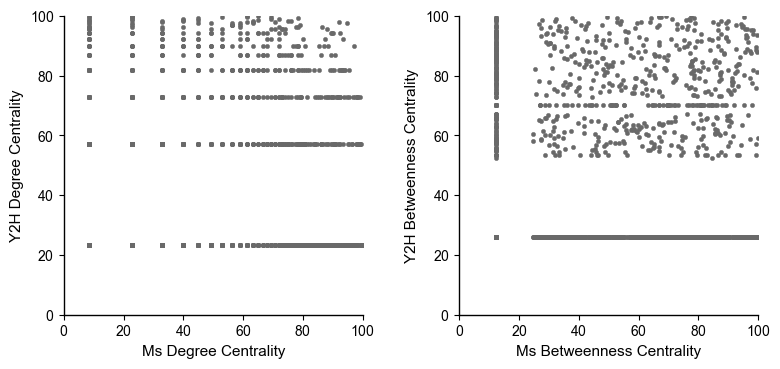

In [2]:
# === 1. IMPORT LIBRARIES AND SET GLOBAL PLOT STYLE ===
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import os

# Set Computer Modern font and clean publication style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10
sns.set_style('ticks')
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# === 2. DEFINE OUTPUT DIRECTORY ===
save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025"
os.makedirs(save_dir, exist_ok=True)

# === 3. DEFINE (x, y) VARIABLE PAIRS AND FILENAMES ===
centrality_pairs = [
    ('MS_degree_centrality_percentile', 'Y2H_degree_centrality_percentile'),
    ('MS_betweenness_centrality_percentile', 'Y2H_betweenness_centrality_percentile')
]

filenames = [
    "1C-a - MS Degree Centrality vs Y2H Degree Centrality",
    "1C-b - MS Betweenness Centrality vs Y2H Betweenness Centrality"
]

# === 4. SET PLOT PANEL LAYOUT (Always 2x4 grid for 7 plots) ===
nrows, ncols = 2, 4
fig, axs = plt.subplots(nrows, ncols, figsize=(16, 8))
axs = axs.flatten()

# === 5. PLOTTING & STATISTICS LOOP ===
for i, (x_col, y_col) in enumerate(centrality_pairs):
    # -- Check if columns exist in dataframe --
    missing_cols = [col for col in (x_col, y_col) if col not in selected_columns.columns]
    if missing_cols:
        print(f"WARNING: Missing columns {missing_cols} in selected_columns. Skipping plot {filenames[i]}.")
        continue

    # -- Clean data --
    data_clean = selected_columns[[x_col, y_col]].dropna()

    # -- Make the scatter plot --
    sns.scatterplot(
        x=x_col, y=y_col, data=data_clean,
        ax=axs[i], color='dimgray', s=10, edgecolor=None
    )

    # -- Clean axis labels --
    x_label = x_col.replace('_percentile', '').replace('_', ' ').title()
    y_label = y_col.replace('_percentile', '').replace('_', ' ').title()

    # -- Consistent axes/spines formatting --
    for spine in axs[i].spines.values():
        spine.set_visible(False)
    axs[i].spines['left'].set_visible(True)
    axs[i].spines['bottom'].set_visible(True)
    axs[i].spines['left'].set_position('zero')
    axs[i].spines['bottom'].set_position('zero')
    axs[i].spines['left'].set_color('black')
    axs[i].spines['bottom'].set_color('black')
    axs[i].spines['left'].set_linewidth(1)
    axs[i].spines['bottom'].set_linewidth(1)

    axs[i].xaxis.set_ticks_position('bottom')
    axs[i].yaxis.set_ticks_position('left')
    axs[i].tick_params(axis='both', which='major', labelsize=10, colors='black')
    axs[i].set_xlabel(x_label, color='black')
    axs[i].set_ylabel(y_label, color='black')
    axs[i].set_xlim(0, 100)
    axs[i].set_ylim(0, 100)
    axs[i].set_aspect('equal')

    # -- Compute and print correlation coefficients --
    if len(data_clean) > 1:  # Avoid crash if not enough data
        pearson_corr, pearson_p = pearsonr(data_clean[x_col], data_clean[y_col])
        spearman_corr, spearman_p = spearmanr(data_clean[x_col], data_clean[y_col])
        print(f"{filenames[i]}: Pearson r = {pearson_corr:.2f} (p={pearson_p:.2e}), "
              f"Spearman ρ = {spearman_corr:.2f} (p={spearman_p:.2e})")
    else:
        print(f"{filenames[i]}: Not enough data points for correlation.")
    slope, intercept = np.polyfit(data_clean[x_col], data_clean[y_col], 1)
    y_pred = slope * data_clean[x_col] + intercept
    ss_res = np.sum((data_clean[y_col] - y_pred) ** 2)
    ss_tot = np.sum((data_clean[y_col] - np.mean(data_clean[y_col])) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    print(f"{filenames[i]}: R² (linear fit) = {r_squared:.2f}")

    # -- Save each individual plot as high-res PNG --
    # single_fig, single_ax = plt.subplots(figsize=(6, 6))
    # sns.scatterplot(
    #     x=x_col, y=y_col, data=data_clean,
    #     ax=single_ax, color='dimgray', s=10, edgecolor=None
    # )
    # # Apply the same formatting for the single plot
    # for spine in single_ax.spines.values():
    #     spine.set_visible(False)
    # single_ax.spines['left'].set_visible(True)
    # single_ax.spines['bottom'].set_visible(True)
    # single_ax.spines['left'].set_position('zero')
    # single_ax.spines['bottom'].set_position('zero')
    # single_ax.spines['left'].set_color('black')
    # single_ax.spines['bottom'].set_color('black')
    # single_ax.spines['left'].set_linewidth(1)
    # single_ax.spines['bottom'].set_linewidth(1)
    # single_ax.xaxis.set_ticks_position('bottom')
    # single_ax.yaxis.set_ticks_position('left')
    # single_ax.tick_params(axis='both', which='major', labelsize=10, colors='black')
    # single_ax.set_xlabel(x_label, color='black')
    # single_ax.set_ylabel(y_label, color='black')
    # single_ax.set_xlim(0, 100)
    # single_ax.set_ylim(0, 100)
    # single_ax.set_aspect('equal')
    # single_fig.tight_layout(pad=2.0)
    # png_path = os.path.join(save_dir, f"{filenames[i]}.png")
    # single_fig.savefig(png_path, dpi=300, bbox_inches='tight')
    # plt.close(single_fig)

# === 6. REMOVE UNUSED SUBPLOTS AND FINALIZE PANEL ===
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout(pad=2.0)
plt.show()

/tmp/ipykernel_1880578/1657932386.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0, rect=[0, 0, 0.90, 1])  # Make space for colorbar


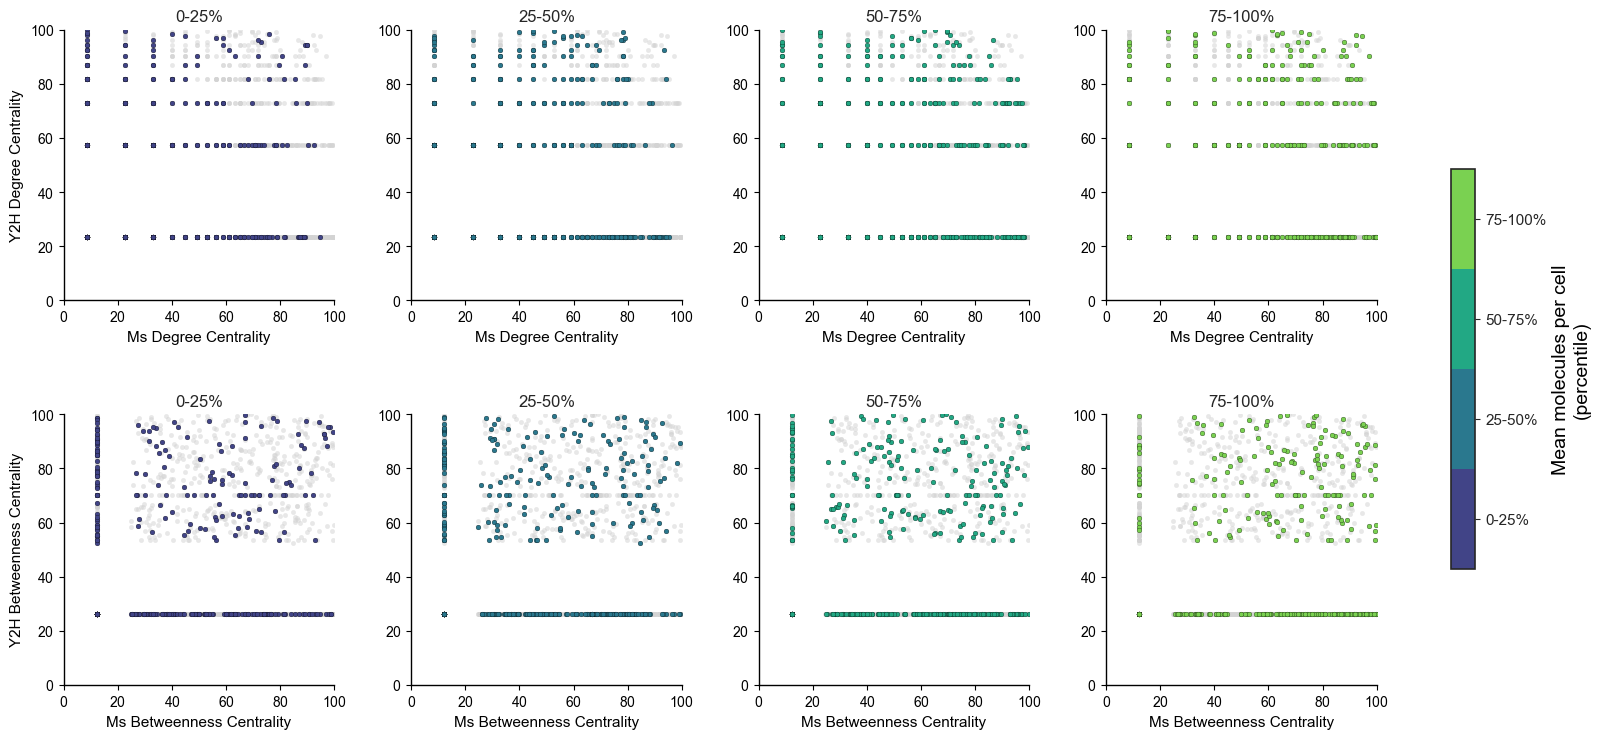

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, Normalize
from matplotlib.cm import ScalarMappable

# 1. CALCULATE PERCENTILE BINS
percentiles = np.percentile(selected_columns['mean_molecules_per_cell'].dropna(), [0, 25, 50, 75, 100])
selected_columns['mol_bin'] = pd.cut(
    selected_columns['mean_molecules_per_cell'],
    bins=percentiles,
    labels=['0-25%', '25-50%', '50-75%', '75-100%'],
    include_lowest=True
)

# 2. COLOR MAP FOR BINS (Make it gradated, like a heatmap)
colors = sns.color_palette('viridis', 4)  # 4 bins
bin_to_color = dict(zip(['0-25%', '25-50%', '50-75%', '75-100%'], colors))

# 3. MAKE PANEL PLOTS, EACH HIGHLIGHTING ONE BIN
centrality_pairs = [
    ('MS_degree_centrality_percentile', 'Y2H_degree_centrality_percentile'),
    ('MS_betweenness_centrality_percentile', 'Y2H_betweenness_centrality_percentile')
]
filenames = [
    "1C-a - MS Degree Centrality vs Y2H Degree Centrality",
    "1C-b - MS Betweenness Centrality vs Y2H Betweenness Centrality"
]
nrows, ncols = 2, 4
fig, axs = plt.subplots(nrows, ncols, figsize=(16, 8))
axs = axs.flatten()

for i, (x_col, y_col) in enumerate(centrality_pairs):
    for j, bin_label in enumerate(['0-25%', '25-50%', '50-75%', '75-100%']):
        ax = axs[i*4 + j]
        data_clean = selected_columns[[x_col, y_col, 'mol_bin']].dropna()
        # Plot GREY points for not-in-bin, COLORED points for in-bin
        in_bin = data_clean['mol_bin'] == bin_label
        sns.scatterplot(
            x=x_col, y=y_col, data=data_clean[~in_bin],
            ax=ax, color='lightgrey', s=10, edgecolor=None, label=None, alpha=0.5
        )
        sns.scatterplot(
            x=x_col, y=y_col, data=data_clean[in_bin],
            ax=ax, color=bin_to_color[bin_label], s=12, edgecolor='black', linewidth=0.2
        )
        # Style
        x_label = x_col.replace('_percentile', '').replace('_', ' ').title()
        y_label = y_col.replace('_percentile', '').replace('_', ' ').title()
        for spine in ax.spines.values(): spine.set_visible(False)
        ax.spines['left'].set_visible(True); ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_position('zero'); ax.spines['bottom'].set_position('zero')
        ax.spines['left'].set_color('black'); ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_linewidth(1); ax.spines['bottom'].set_linewidth(1)
        ax.xaxis.set_ticks_position('bottom'); ax.yaxis.set_ticks_position('left')
        ax.tick_params(axis='both', which='major', labelsize=10, colors='black')
        ax.set_xlabel(x_label, color='black')
        ax.set_ylabel(y_label if j == 0 else '', color='black')
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.set_aspect('equal')
        ax.set_title(f"{bin_label}", fontsize=12)
        #if j == 0:
            #ax.legend(loc='upper left', frameon=False)
        #else:
            #ax.get_legend().remove()

# 4. COLORBAR / LEGEND
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
cmap = ListedColormap(colors)
norm = Normalize(vmin=0, vmax=100)
sm = ScalarMappable(norm=norm, cmap=cmap)
cb = plt.colorbar(sm, cax=cbar_ax, ticks=[12.5, 37.5, 62.5, 87.5])
cb.ax.set_yticklabels(['0-25%', '25-50%', '50-75%', '75-100%'])
cb.set_label('Mean molecules per cell\n(percentile)', fontsize=14, color='black')

# 5. REMOVE UNUSED SUBPLOTS (if any)
for k in range(2*4, len(axs)):
    fig.delaxes(axs[k])

plt.tight_layout(pad=2.0, rect=[0, 0, 0.90, 1])  # Make space for colorbar
# panel_png_path = os.path.join(save_dir, "centrality_vs_centrality_colored_by_molecules_panel.png")
# fig.savefig(panel_png_path, dpi=300, bbox_inches='tight')
plt.show()

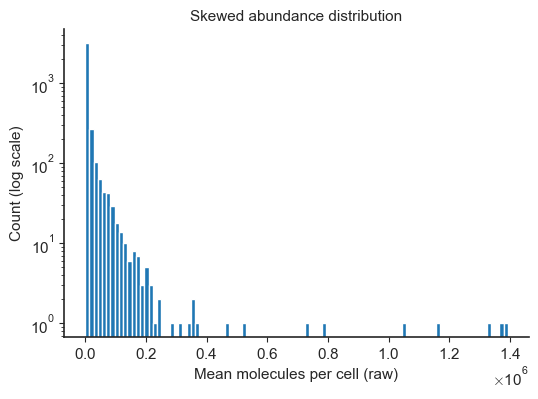

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.hist(selected_columns['mean_molecules_per_cell'].dropna(), bins=100, log=True)
plt.xlabel('Mean molecules per cell (raw)')
plt.ylabel('Count (log scale)')
plt.title('Skewed abundance distribution')
plt.show()

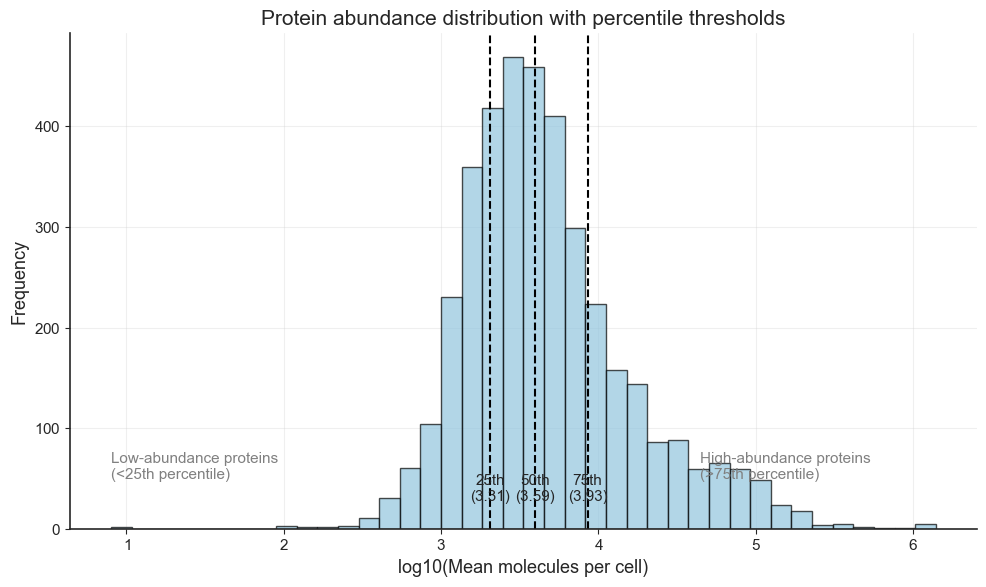

count    3853.000000
mean        3.675353
std         0.539232
min         0.903090
25%         3.312600
50%         3.594834
75%         3.930338
max         6.143826
Name: mean_molecules_per_cell, dtype: float64


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---- STEP 1: Load your data ----
# Replace with your actual filename
abundance = selected_columns['mean_molecules_per_cell'].dropna()

# Replace 'mean_molecules_per_cell' with your actual column name
abundance = df['mean_molecules_per_cell'].dropna()

# ---- STEP 2: Log-transform the abundance (to compress large scale differences) ----
log_abundance = np.log10(abundance + 1)  # add 1 to avoid log(0)

# ---- STEP 3: Compute percentiles ----
percentile_values = np.percentile(log_abundance, [25, 50, 75])
percentile_labels = ['25th', '50th', '75th']

# ---- STEP 4: Plot the distribution ----
plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(log_abundance, bins=40, color='#92c5de', edgecolor='black', alpha=0.7)
plt.xlabel('log10(Mean molecules per cell)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.title('Protein abundance distribution with percentile thresholds', fontsize=15)

# ---- STEP 5: Add percentile lines ----
for p, label in zip(percentile_values, percentile_labels):
    plt.axvline(p, color='black', linestyle='--', linewidth=1.5)
    plt.text(p, plt.ylim()[1]*0.05, f"{label}\n({p:.2f})", ha='center', va='bottom', fontsize=11)

# ---- STEP 6: Annotate regions ----
plt.text(np.min(log_abundance), plt.ylim()[1]*0.1, "Low-abundance proteins\n(<25th percentile)", color='gray', fontsize=11)
plt.text(np.max(log_abundance)-1.5, plt.ylim()[1]*0.1, "High-abundance proteins\n(>75th percentile)", color='gray', fontsize=11)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---- STEP 7 (optional): Display summary statistics ----
summary = pd.Series(log_abundance).describe(percentiles=[0.25, 0.5, 0.75])
print(summary)




=== Summary statistics ===
            Group          mean          sem  count
0   MS Bottom 90%  10695.834783   713.253332   3450
1      MS Top 10%  47926.046753  6317.196980    385
2  Y2H Bottom 90%  12063.150271  1315.877545   1291
3     Y2H Top 10%   9472.184524  1611.539664    168

=== Mann–Whitney U Tests ===
MS hubs vs MS non-hubs: U=nan, p=nan, n1=385, n2=3474
Y2H hubs vs Y2H non-hubs: U=nan, p=nan, n1=168, n2=1294
MS hubs vs Y2H hubs: U=48094.50, p=7.739e-20, n1=385, n2=168
MS non-hubs vs Y2H non-hubs: U=nan, p=nan, n1=3474, n2=1294


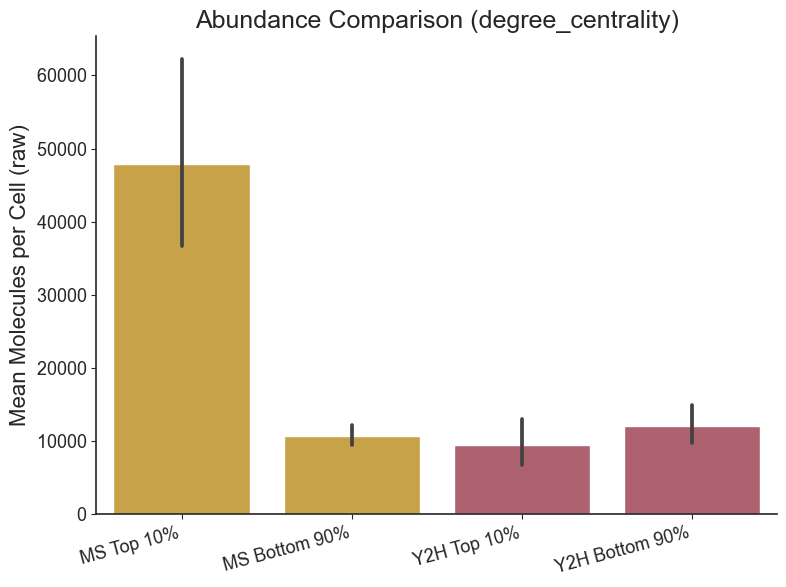


=== Summary statistics ===
            Group          mean          sem  count
0   MS Bottom 90%  11789.984620   729.106566   3446
1      MS Top 10%  37850.568123  6244.337313    389
2  Y2H Bottom 90%  12319.115091  1305.095832   1312
3     Y2H Top 10%   6817.517007  1054.193040    147

=== Mann–Whitney U Tests ===
MS hubs vs MS non-hubs: U=nan, p=nan, n1=390, n2=3469
Y2H hubs vs Y2H non-hubs: U=nan, p=nan, n1=147, n2=1315
MS hubs vs Y2H hubs: U=nan, p=nan, n1=390, n2=147
MS non-hubs vs Y2H non-hubs: U=nan, p=nan, n1=3469, n2=1315


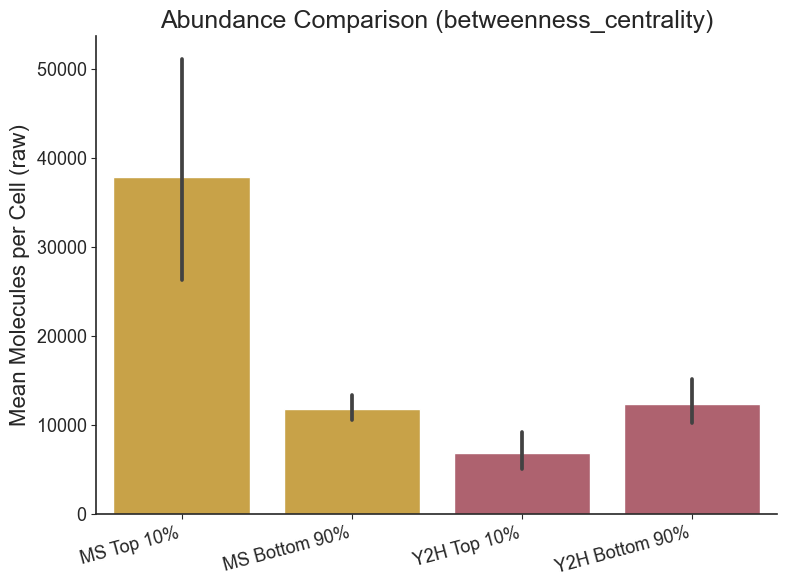

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import os

def test_hub_abundance(selected_columns, ms_col, y2h_col, save_dir, metric_name):
    # === Define groups ===
    hubs_ms = selected_columns[selected_columns[ms_col] >= 90]['mean_molecules_per_cell']
    nonhubs_ms = selected_columns[selected_columns[ms_col] < 90]['mean_molecules_per_cell']
    hubs_y2h = selected_columns[selected_columns[y2h_col] >= 90]['mean_molecules_per_cell']
    nonhubs_y2h = selected_columns[selected_columns[y2h_col] < 90]['mean_molecules_per_cell']
    data = pd.DataFrame({
        'Group': ['MS Top 10%'] * len(hubs_ms) +
                 ['MS Bottom 90%'] * len(nonhubs_ms) +
                 ['Y2H Top 10%'] * len(hubs_y2h) +
                 ['Y2H Bottom 90%'] * len(nonhubs_y2h),
        'mean_molecules_per_cell': np.concatenate([hubs_ms, nonhubs_ms, hubs_y2h, nonhubs_y2h])
    })
    # === Compute summary stats ===
    summary = data.groupby('Group')['mean_molecules_per_cell'].agg(['mean', 'sem', 'count']).reset_index()
    print("\n=== Summary statistics ===")
    print(summary)
    # === Statistical tests ===
    print("\n=== Mann–Whitney U Tests ===")
    tests = [
        ('MS hubs vs MS non-hubs', hubs_ms, nonhubs_ms),
        ('Y2H hubs vs Y2H non-hubs', hubs_y2h, nonhubs_y2h),
        ('MS hubs vs Y2H hubs', hubs_ms, hubs_y2h),
        ('MS non-hubs vs Y2H non-hubs', nonhubs_ms, nonhubs_y2h)
    ]
    for name, g1, g2 in tests:
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        print(f"{name}: U={stat:.2f}, p={p:.4g}, n1={len(g1)}, n2={len(g2)}")
    # === Plot ===
    plt.figure(figsize=(8,6))
    sns.barplot(data=data, x='Group', y='mean_molecules_per_cell', palette=['#DDAA33', '#DDAA33', '#BB5566', '#BB5566'])
    plt.ylabel('Mean Molecules per Cell (raw)', fontsize=16)
    plt.xlabel('')
    plt.xticks(rotation=15, ha='right', fontsize=13)
    plt.yticks(fontsize=13)
    plt.title(f'Abundance Comparison ({metric_name})', fontsize=18)
    sns.despine()
    plt.tight_layout()
    #save_path = os.path.join(save_dir, f"{metric_name}_abundance_boxplot_raw.png")
    #plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()

# === Run for degree and betweenness ===
test_hub_abundance(
    selected_columns,
    ms_col='MS_degree_centrality_percentile',
    y2h_col='Y2H_degree_centrality_percentile',
    save_dir=save_dir,
    metric_name='degree_centrality'
)
test_hub_abundance(
    selected_columns,
    ms_col='MS_betweenness_centrality_percentile',
    y2h_col='Y2H_betweenness_centrality_percentile',
    save_dir=save_dir,
    metric_name='betweenness_centrality'
)

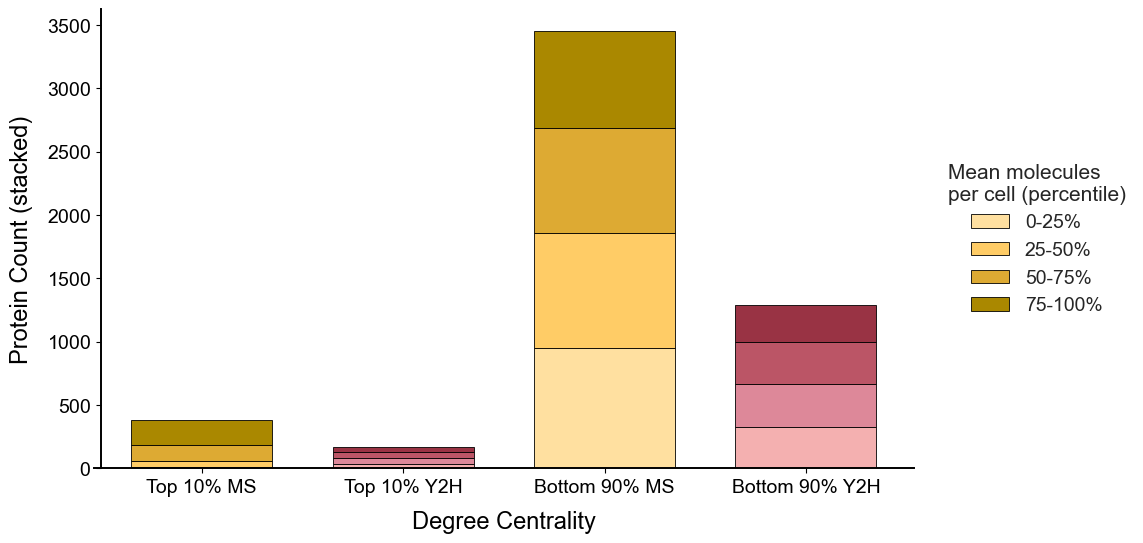


Counts of proteins per group and per mean molecule percentile bin for degree_centrality:
         Top 10% MS  Top 10% Y2H  Bottom 90% MS  Bottom 90% Y2H
0-25%             8           36            951             324
25-50%           51           46            909             345
50-75%          128           44            830             332
75-100%         198           42            760             290
--------------------------------------------------------------------------------
Fractions of proteins per group and per mean molecule percentile bin for degree_centrality:
         Top 10% MS  Top 10% Y2H  Bottom 90% MS  Bottom 90% Y2H
0-25%         0.021        0.214          0.274           0.250
25-50%        0.132        0.274          0.262           0.267
50-75%        0.332        0.262          0.239           0.257
75-100%       0.514        0.250          0.219           0.224
--------------------------------------------------------------------------------
Proteins per gro

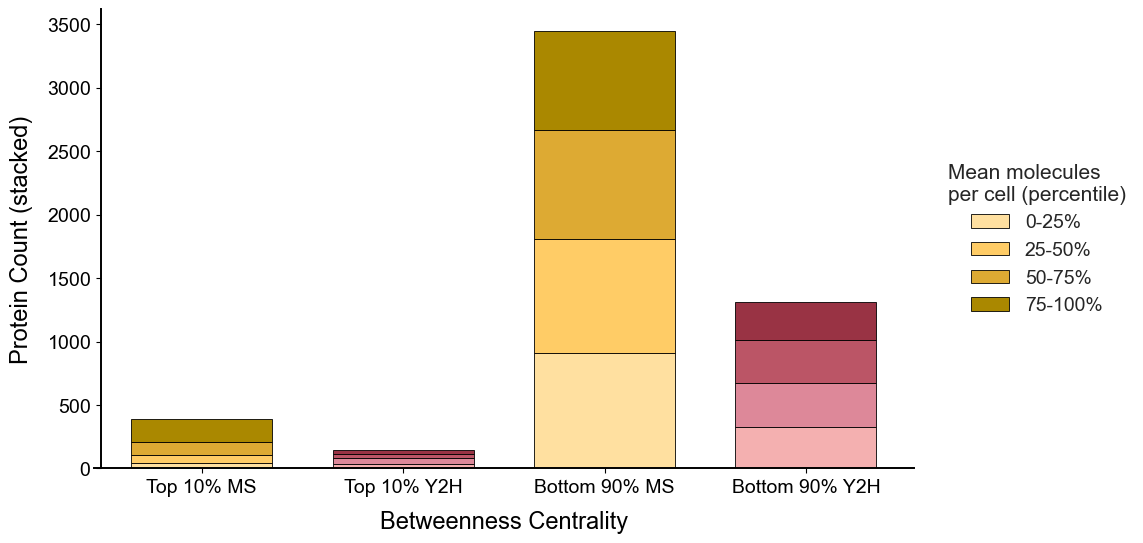


Counts of proteins per group and per mean molecule percentile bin for betweenness_centrality:
         Top 10% MS  Top 10% Y2H  Bottom 90% MS  Bottom 90% Y2H
0-25%            46           37            913             323
25-50%           61           44            899             347
50-75%           99           35            859             341
75-100%         183           31            775             301
--------------------------------------------------------------------------------
Fractions of proteins per group and per mean molecule percentile bin for betweenness_centrality:
         Top 10% MS  Top 10% Y2H  Bottom 90% MS  Bottom 90% Y2H
0-25%         0.118        0.252          0.263           0.246
25-50%        0.156        0.299          0.259           0.264
50-75%        0.254        0.238          0.248           0.259
75-100%       0.469        0.211          0.223           0.229
--------------------------------------------------------------------------------
Protei

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === Permutation Test on Fractions ===
def permutation_test_fraction(selected_columns, group_mask, bin_label, n_permutations=10000, random_state=42):
    np.random.seed(random_state)
    # Observed
    n_in_group = group_mask.sum()
    if n_in_group == 0:
        return np.nan, np.nan, np.nan
    observed = (selected_columns[group_mask]['mean_mol_bin'] == bin_label).sum()
    observed_fraction = observed / n_in_group
    # Permutation
    all_labels = selected_columns['mean_mol_bin'].dropna().values
    permuted_fractions = []
    for _ in range(n_permutations):
        permuted_bins = np.random.choice(all_labels, size=n_in_group, replace=False)
        permuted_fractions.append((permuted_bins == bin_label).sum() / n_in_group)
    p_value = (np.sum(np.array(permuted_fractions) >= observed_fraction) + 1) / (n_permutations + 1)
    return observed_fraction, np.mean(permuted_fractions), p_value

def plot_stacked_bar_for_centrality(selected_columns, ms_col, y2h_col, centrality_name, save_dir):
    # 1. Bin by mean molecules per cell (don't overwrite globally!)
    selected_columns = selected_columns.copy()
    selected_columns['mean_mol_bin'] = pd.cut(
        selected_columns['mean_molecules_per_cell'],
        bins=np.percentile(selected_columns['mean_molecules_per_cell'].dropna(), [0, 25, 50, 75, 100]),
        labels=['0-25%', '25-50%', '50-75%', '75-100%'],
        include_lowest=True
    )

    # 2. Define groups for this centrality metric
    groups = {
        f'Top 10% MS {centrality_name}': selected_columns[ms_col] >= 90,
        f'Top 10% Y2H {centrality_name}': selected_columns[y2h_col] >= 90,
        f'Bottom 90% MS {centrality_name}': selected_columns[ms_col] < 90,
        f'Bottom 90% Y2H {centrality_name}': selected_columns[y2h_col] < 90,
    }
    pretty_labels = [
        f'Top 10% MS', f'Top 10% Y2H', f'Bottom 90% MS', f'Bottom 90% Y2H'
    ]
    percentile_labels = ['0-25%', '25-50%', '50-75%', '75-100%']
    
    # Generate light-to-dark shades for MS (#DDAA33) and Y2H (#BB5566)
    ms_colors = ['#FFE0A0', '#FFCC66', '#DDAA33', '#AA8800']  # light → dark
    y2h_colors = ['#F4B0B0', '#DD8899', '#BB5566', '#993344']  # light → dark

    # Assign colors to bins based on group type
    bin_to_color = {}
    for i, bin_label in enumerate(percentile_labels):
        bin_to_color[bin_label] = [ms_colors[i], y2h_colors[i], ms_colors[i], y2h_colors[i]]

    # 3. Compute counts and fractions
    bar_counts = []
    bar_fractions = []
    n_proteins_in_group = []
    for group_name, mask in groups.items():
        sub_counts = selected_columns[mask]['mean_mol_bin'].value_counts().reindex(percentile_labels, fill_value=0)
        n_total = mask.sum()
        n_proteins_in_group.append(n_total)
        bar_counts.append(sub_counts.values)
        if n_total > 0:
            bar_fractions.append(sub_counts.values / n_total)
        else:
            bar_fractions.append(np.zeros_like(sub_counts.values))
    bar_counts = np.array(bar_counts).T  # shape: (4 percentiles, 4 groups)
    bar_fractions = np.array(bar_fractions).T

    # 4. Plot (still shows *counts* stacked, as before)
    fig, ax = plt.subplots(figsize=(12, 6))
    bar_positions = np.arange(len(pretty_labels)) + 0.5

    bottoms = np.zeros(len(pretty_labels))
    for i, bin_label in enumerate(percentile_labels):
        bars = ax.bar(
            bar_positions, bar_counts[i], bottom=bottoms,
            color=bin_to_color[bin_label], edgecolor='black', linewidth=0.6,
            width=0.7, label=bin_label
        )
        bottoms += bar_counts[i]

    # Axis labels and ticks
    ax.set_xlabel(f'{centrality_name.replace("_centrality", "").capitalize()} Centrality', fontsize=17, color='black', labelpad=10)
    ax.set_ylabel('Protein Count (stacked)', fontsize=17, color='black', labelpad=10)
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(pretty_labels, fontsize=14, color='black', rotation=15, ha='right')
    ax.tick_params(axis='y', which='major', labelsize=14, colors='black')
    ax.tick_params(axis='x', which='major', labelsize=14, colors='black')

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(1.4)
    ax.spines['bottom'].set_linewidth(1.4)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(
        [by_label[l] for l in percentile_labels],
        percentile_labels,
        title='Mean molecules\nper cell (percentile)',
        loc='center left', bbox_to_anchor=(1.02, 0.5),
        frameon=False, fontsize=14, title_fontsize=15
    )

    fig.subplots_adjust(left=0.10, right=0.80, bottom=0.23, top=0.95)
    fig.tight_layout(pad=2.5)
    #barplot_path = os.path.join(save_dir, f"{centrality_name}_molecule_percentile_stacked_bar_PRESENTABLE.png")
    #fig.savefig(barplot_path, dpi=600, bbox_inches='tight')
    plt.show()

    # Print tables (counts & fractions)
    table_counts = pd.DataFrame(bar_counts, index=percentile_labels, columns=pretty_labels)
    table_fractions = pd.DataFrame(bar_fractions, index=percentile_labels, columns=pretty_labels)
    print(f"\nCounts of proteins per group and per mean molecule percentile bin for {centrality_name}:")
    print(table_counts)
    print('-'*80)
    print(f"Fractions of proteins per group and per mean molecule percentile bin for {centrality_name}:")
    print(table_fractions.round(3))
    print('-'*80)
    print("Proteins per group:", dict(zip(pretty_labels, n_proteins_in_group)))

    # Permutation test (on fractions)
    print(f"\nPermutation test results (for each bar; fractions):")
    for group_idx, (group_name, mask) in enumerate(groups.items()):
        for bin_idx, bin_label in enumerate(percentile_labels):
            obs_frac, exp_frac, pval = permutation_test_fraction(selected_columns, mask, bin_label)
            signif = ''
            if np.isnan(pval):
                print(f"{group_name} | {bin_label}: N/A")
                continue
            if pval < 0.001: signif = '***'
            elif pval < 0.01: signif = '**'
            elif pval < 0.05: signif = '*'
            print(f"{group_name} | {bin_label}: Observed={obs_frac:.3f}, Expected={exp_frac:.3f}, p={pval:.4g} {signif}")
    print('-'*80)

# === USAGE: CALL THE FUNCTION FOR BOTH METRICS ===

plot_stacked_bar_for_centrality(
    selected_columns,
    'MS_degree_centrality_percentile',
    'Y2H_degree_centrality_percentile',
    'degree_centrality',
    save_dir
)

plot_stacked_bar_for_centrality(
    selected_columns,
    'MS_betweenness_centrality_percentile',
    'Y2H_betweenness_centrality_percentile',
    'betweenness_centrality',
    save_dir
)


=== Percentage Differences for Degree Centrality ===
Hubs MS are 163.70% greater than Non-hubs MS (medians: 9306.00 vs 3529.00)
Hubs Y2H are 9.21% greater than Non-hubs Y2H (medians: 4073.50 vs 3730.00)

=== Mann–Whitney U Tests (log-transformed) for Degree Centrality ===
MS hubs vs MS non-hubs: U=1017730.00, p=5.249e-66, n1=385, n2=3450
Y2H hubs vs Y2H non-hubs: U=112569.50, p=0.422, n1=168, n2=1291

=== Kolmogorov-Smirnov Tests (log-transformed) for Degree Centrality ===
MS hubs vs MS non-hubs: KS=0.40, p=6.093e-50, n1=385, n2=3450
Y2H hubs vs Y2H non-hubs: KS=0.06, p=0.6148, n1=168, n2=1291


/tmp/ipykernel_1880578/2501613592.py:77: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su


=== Percentage Differences for Betweenness Centrality ===
Hubs MS are 120.53% greater than Non-hubs MS (medians: 8035.00 vs 3643.50)
Hubs Y2H are -9.86% greater than Non-hubs Y2H (medians: 3419.00 vs 3793.00)

=== Mann–Whitney U Tests (log-transformed) for Betweenness Centrality ===
MS hubs vs MS non-hubs: U=911600.00, p=2.058e-31, n1=389, n2=3446
Y2H hubs vs Y2H non-hubs: U=90601.50, p=0.2288, n1=147, n2=1312

=== Kolmogorov-Smirnov Tests (log-transformed) for Betweenness Centrality ===
MS hubs vs MS non-hubs: KS=0.27, p=1.712e-23, n1=389, n2=3446
Y2H hubs vs Y2H non-hubs: KS=0.07, p=0.4483, n1=147, n2=1312


/tmp/ipykernel_1880578/2501613592.py:77: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su

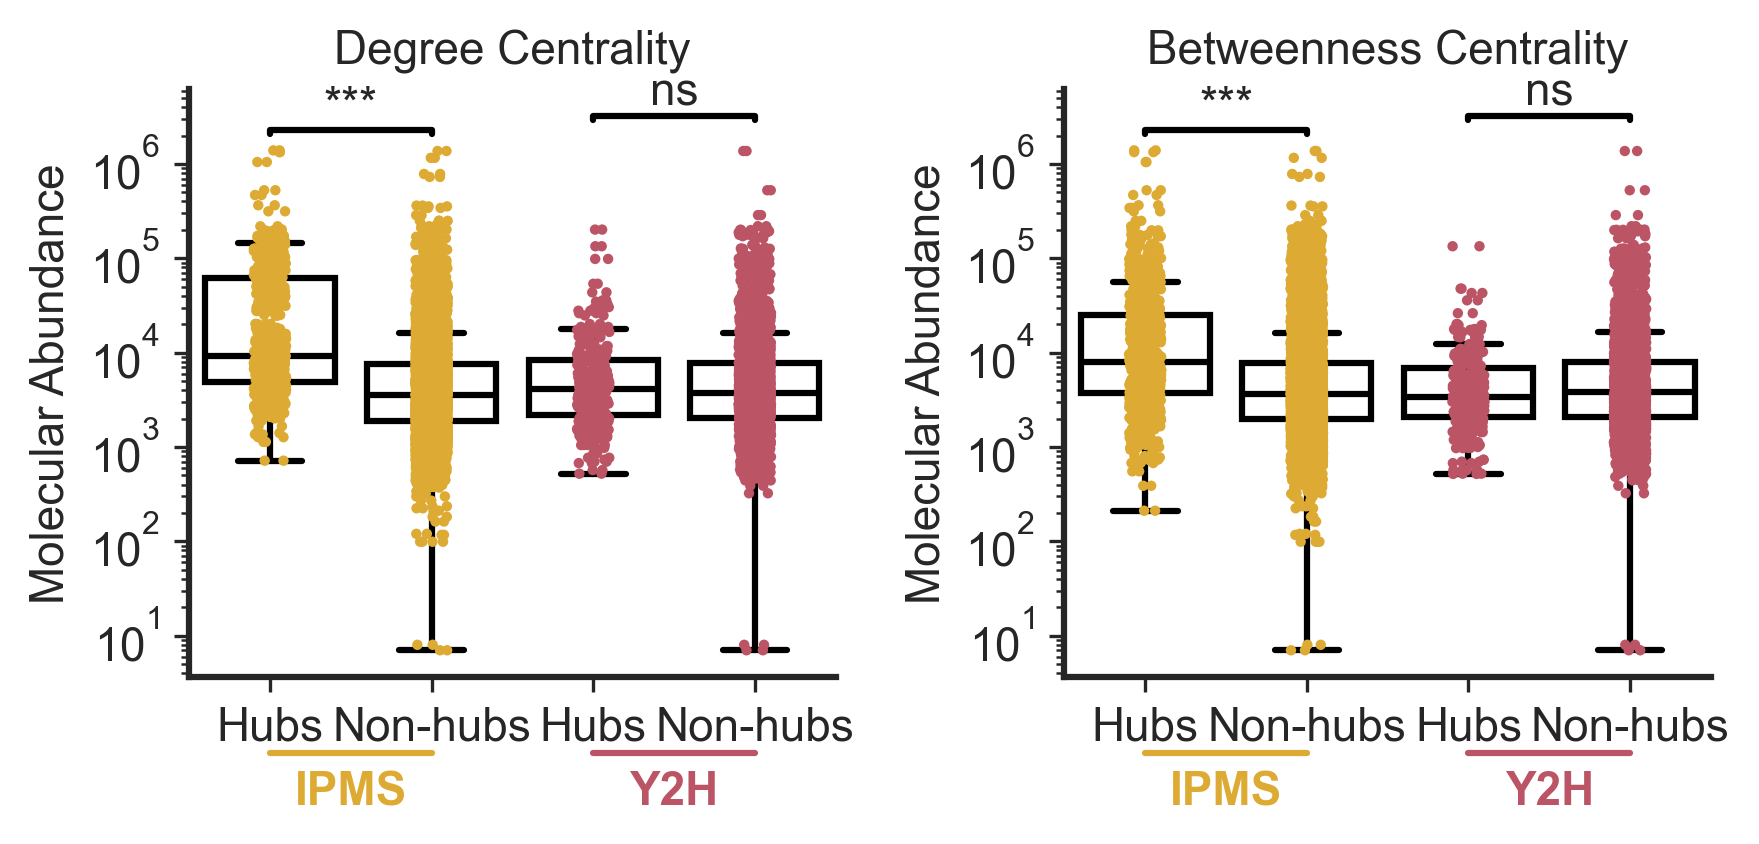

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ks_2samp
import os
# Set global font settings for publication quality
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300
def test_hub_abundance_boxplot(selected_columns, ms_col, y2h_col, save_dir, metric_name, ax=None, save=True, show=True, print_stats=True):
    # === Define hub vs non-hub groups ===
    hubs_ms = selected_columns[selected_columns[ms_col] >= 90]['mean_molecules_per_cell'].dropna()
    nonhubs_ms = selected_columns[selected_columns[ms_col] < 90]['mean_molecules_per_cell'].dropna()
    hubs_y2h = selected_columns[selected_columns[y2h_col] >= 90]['mean_molecules_per_cell'].dropna()
    nonhubs_y2h = selected_columns[selected_columns[y2h_col] < 90]['mean_molecules_per_cell'].dropna()
   
    # === Combine into a single dataframe ===
    data = pd.DataFrame({
        'Group': (['Hubs MS'] * len(hubs_ms)) +
                 (['Non-hubs MS'] * len(nonhubs_ms)) +
                 (['Hubs Y2H'] * len(hubs_y2h)) +
                 (['Non-hubs Y2H'] * len(nonhubs_y2h)),
        'abundance': np.concatenate([hubs_ms, nonhubs_ms, hubs_y2h, nonhubs_y2h])
    })
   
    # === Mann–Whitney tests (on log-transformed data for statistical test) ===
    if print_stats:
        print(f"\n=== Percentage Differences for {metric_name} ===")
        hubs_ms_median = np.median(hubs_ms)
        nonhubs_ms_median = np.median(nonhubs_ms)
        percentage_ms = ((hubs_ms_median - nonhubs_ms_median) / nonhubs_ms_median) * 100 if nonhubs_ms_median != 0 else 0 #CALCULATIONS FOR PERCENTAGE
        print(f"Hubs MS are {percentage_ms:.2f}% greater than Non-hubs MS (medians: {hubs_ms_median:.2f} vs {nonhubs_ms_median:.2f})")
        hubs_y2h_median = np.median(hubs_y2h)
        nonhubs_y2h_median = np.median(nonhubs_y2h)
        percentage_y2h = ((hubs_y2h_median - nonhubs_y2h_median) / nonhubs_y2h_median) * 100 if nonhubs_y2h_median != 0 else 0
        print(f"Hubs Y2H are {percentage_y2h:.2f}% greater than Non-hubs Y2H (medians: {hubs_y2h_median:.2f} vs {nonhubs_y2h_median:.2f})")

        print(f"\n=== Mann–Whitney U Tests (log-transformed) for {metric_name} ===")
        def log_transform(series):
            return np.log10(series + 1) # Add 1 to avoid log(0)
        tests = [
            ('MS hubs vs MS non-hubs', log_transform(hubs_ms), log_transform(nonhubs_ms)),
            ('Y2H hubs vs Y2H non-hubs', log_transform(hubs_y2h), log_transform(nonhubs_y2h))
        ]
        p_values = []
        for name, g1, g2 in tests:
            stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
            print(f"{name}: U={stat:.2f}, p={p:.4g}, n1={len(g1)}, n2={len(g2)}")
            p_values.append(p)

        print(f"\n=== Kolmogorov-Smirnov Tests (log-transformed) for {metric_name} ===")
        for name, g1, g2 in tests:
            stat, p = ks_2samp(g1, g2)
            print(f"{name}: KS={stat:.2f}, p={p:.4g}, n1={len(g1)}, n2={len(g2)}")
    else:
        # Still compute p_values even if not printing
        def log_transform(series):
            return np.log10(series + 1)
        tests = [
            (log_transform(hubs_ms), log_transform(nonhubs_ms)),
            (log_transform(hubs_y2h), log_transform(nonhubs_y2h))
        ]
        p_values = [mannwhitneyu(g1, g2, alternative='two-sided')[1] for g1, g2 in tests]
   
    # === Create ax if not provided ===
    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(3, 3))
        ax = fig.add_subplot(111)
   
    # === Plot: Boxplot + swarm overlay ===
    sns.stripplot(
        data=data,
        x='Group',
        y='abundance', # Use original mean_molecules_per_cell data
        palette={'Hubs MS': '#DDAA33', 'Non-hubs MS': '#DDAA33',
                 'Hubs Y2H': '#BB5566', 'Non-hubs Y2H': '#BB5566'},
        size=2.5,
        alpha=1.0,
        jitter=True,
        ax=ax
    )
    sns.boxplot(
        data=data,
        x='Group',
        y='abundance', # Use original mean_molecules_per_cell data
        palette={'Hubs MS': '#DDAA33', 'Non-hubs MS': '#DDAA33',
                 'Hubs Y2H': '#BB5566', 'Non-hubs Y2H': '#BB5566'},
        showcaps=True,
        showfliers=False,
        fliersize=2,
        linewidth=1.5,
        boxprops={'edgecolor': 'black'},
        whiskerprops={'color': 'black', 'linewidth': 1.5},
        capprops={'color': 'black', 'linewidth': 1.5},
        medianprops={'color': 'black', 'linewidth': 1.5},
        width=0.8,
        ax=ax
    )
    for i, artist in enumerate(ax.patches):
        artist.set_facecolor('none')
        artist.set_edgecolor('black')
    sns.stripplot(
        data=data,
        x='Group',
        y='abundance', # Use original mean_molecules_per_cell data
        palette={'Hubs MS': '#DDAA33', 'Non-hubs MS': '#DDAA33',
                 'Hubs Y2H': '#BB5566', 'Non-hubs Y2H': '#BB5566'},
        size=2.5,
        alpha=1.0,
        jitter=True,
        ax=ax
    )
   
    # === Set y-axis to logarithmic scale ===
    ax.set_yscale('log')
    ax.set_ylabel('Molecular Abundance')
    ax.set_xlabel('')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['Hubs', 'Non-hubs', 'Hubs', 'Non-hubs'], rotation=0, ha='center')
   
    # === Add significance bars ===
    def add_significance_bar(x1, x2, y, p_value, ax, force_ns=False):
        height = y
        ax.plot([x1, x1, x2, x2], [height, height * 1.1, height * 1.1, height], lw=1.5, c='black')
        stars = 'ns' if force_ns or p_value >= 0.05 else '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*'
        ax.text((x1 + x2) * 0.5, height * 1.15, stars, ha='center', va='bottom', fontfamily='Arial', fontsize=11)
   
    max_y = data['abundance'].max()
    y_start = max_y * 1.5
    y_offset = 1.4
    comparisons = [(0, 1, 0), (2, 3, 1)]
    for idx, (x1, x2, test_idx) in enumerate(comparisons):
        force_ns = (test_idx == 1)
        add_significance_bar(x1, x2, y_start * (y_offset ** idx), p_values[test_idx], ax, force_ns=force_ns)
   
    # Add horizontal lines under MS and Y2H pairs
    ax.plot([0, 1], [-0.13, -0.13], color='#DDAA33', lw=1.5, clip_on=False, transform=ax.get_xaxis_transform())
    ax.plot([2, 3], [-0.13, -0.13], color='#BB5566', lw=1.5, clip_on=False, transform=ax.get_xaxis_transform())
    ax.text(0.5, -0.16, 'IPMS', ha='center', va='top', fontfamily='Arial', fontsize=11, transform=ax.get_xaxis_transform(), color='#DDAA33', fontweight='bold')
    ax.text(2.5, -0.16, 'Y2H', ha='center', va='top', fontfamily='Arial', fontsize=11, transform=ax.get_xaxis_transform(), color='#BB5566', fontweight='bold')
   
    ax.set_title(f'{metric_name}')
    sns.despine(ax=ax)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
   
    # === Save + show ===
    if save:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, {
            'Degree Centrality': '2A-abundance-degree-centrality',
            'Betweenness Centrality': '2B-abundance-betweenness-centrality'
        }[metric_name] + '.svg')
        ax.get_figure().savefig(save_path, dpi=300, bbox_inches='tight')
   
    if standalone:
        if show:
            plt.show()
        else:
            plt.close(ax.get_figure())
# === Example: loop over both centrality metrics ===
save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE2"
metrics = [
    ('MS_degree_centrality_percentile', 'Y2H_degree_centrality_percentile', 'Degree Centrality'),
    ('MS_betweenness_centrality_percentile', 'Y2H_betweenness_centrality_percentile', 'Betweenness Centrality')
]
# Save individual plots (with stats printed)
for ms_col, y2h_col, metric_name in metrics:
    test_hub_abundance_boxplot(selected_columns, ms_col, y2h_col, save_dir, metric_name, ax=None, save=True, show=False, print_stats=True)
# Display adjacent plots (no additional prints)
fig, axs = plt.subplots(1, 2, figsize=(6, 3))
for i, (ms_col, y2h_col, metric_name) in enumerate(metrics):
    test_hub_abundance_boxplot(selected_columns, ms_col, y2h_col, save_dir, metric_name, ax=axs[i], save=False, show=False, print_stats=False)
plt.tight_layout()
plt.show()

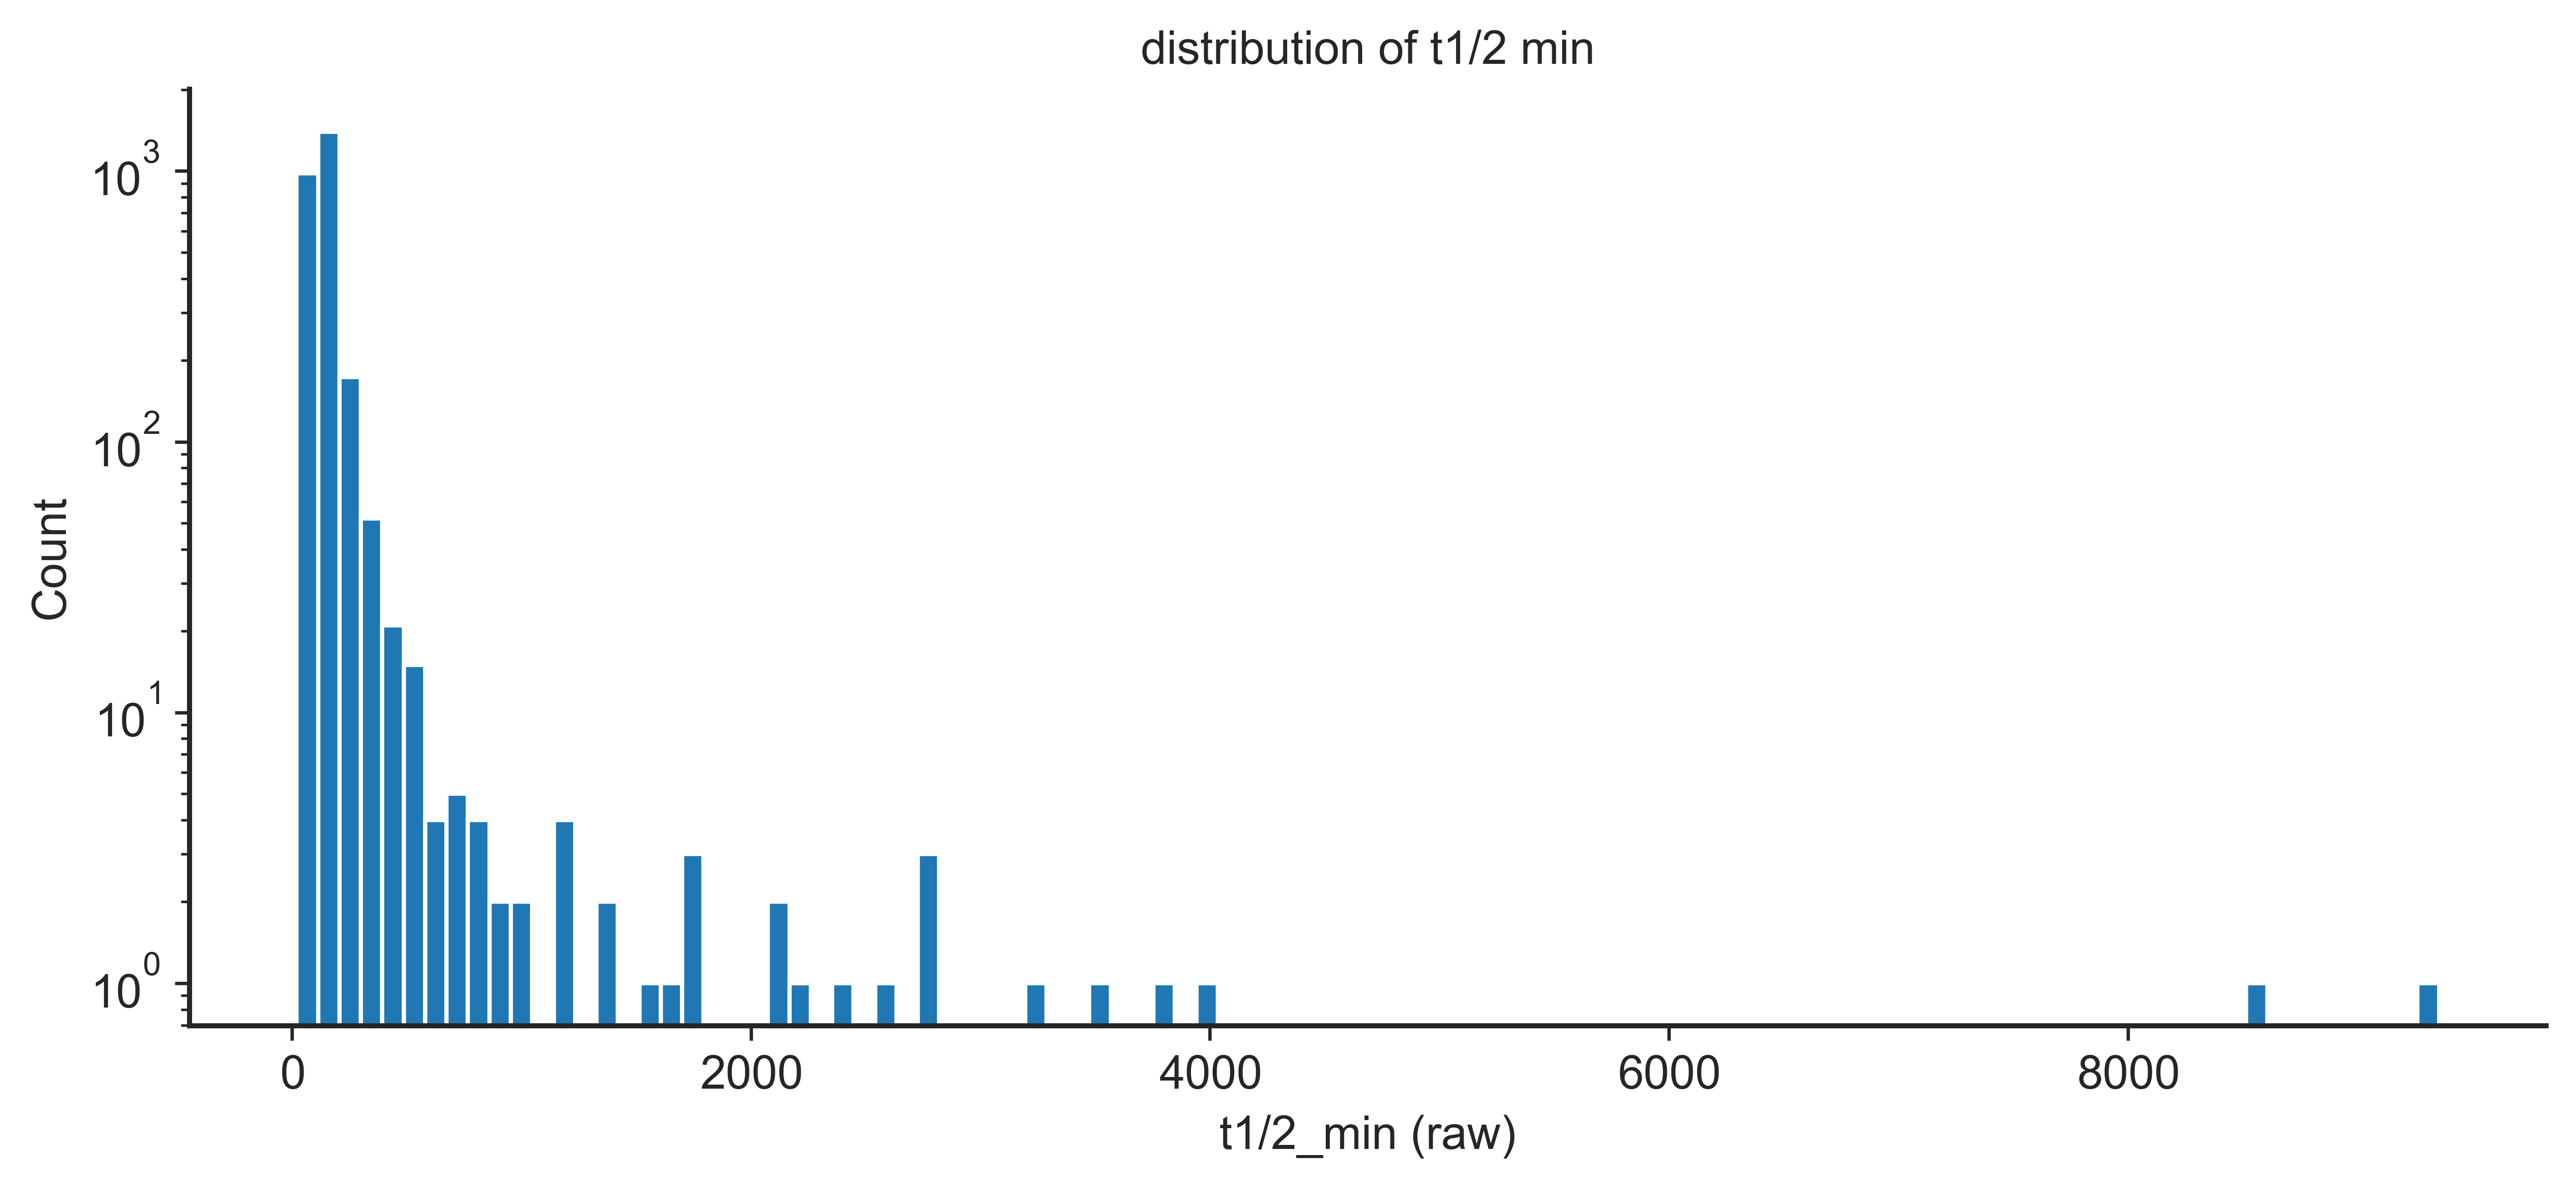

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.hist(selected_columns['Villen_halflife_min'].dropna(), bins=100, log=True)
plt.xlabel('t1/2_min (raw)')
plt.ylabel('Count')
plt.title('distribution of t1/2 min')
plt.show()


=== Percentage Differences for Degree Centrality ===
Hubs MS are -31.70% greater than Non-hubs MS (medians: 91.80 vs 134.40)
Hubs Y2H are 8.60% greater than Non-hubs Y2H (medians: 144.00 vs 132.60)

=== Mann–Whitney U Tests (log-transformed) for Degree Centrality ===
MS hubs vs MS non-hubs: U=225045.50, p=4.962e-37, n1=336, n2=2343
Y2H hubs vs Y2H non-hubs: U=64330.00, p=0.004856, n1=120, n2=926

=== Kolmogorov-Smirnov Tests (log-transformed) for Degree Centrality ===
MS hubs vs MS non-hubs: KS=0.40, p=7.57e-44, n1=336, n2=2343
Y2H hubs vs Y2H non-hubs: KS=0.16, p=0.01067, n1=120, n2=926


/tmp/ipykernel_1880578/766971391.py:80: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_sub


=== Percentage Differences for Betweenness Centrality ===
Hubs MS are -2.98% greater than Non-hubs MS (medians: 126.90 vs 130.80)
Hubs Y2H are 6.79% greater than Non-hubs Y2H (medians: 141.60 vs 132.60)

=== Mann–Whitney U Tests (log-transformed) for Betweenness Centrality ===
MS hubs vs MS non-hubs: U=362287.00, p=0.1044, n1=326, n2=2353
Y2H hubs vs Y2H non-hubs: U=54445.50, p=0.01983, n1=101, n2=945

=== Kolmogorov-Smirnov Tests (log-transformed) for Betweenness Centrality ===
MS hubs vs MS non-hubs: KS=0.06, p=0.2899, n1=326, n2=2353
Y2H hubs vs Y2H non-hubs: KS=0.15, p=0.03658, n1=101, n2=945


/tmp/ipykernel_1880578/766971391.py:80: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_sub

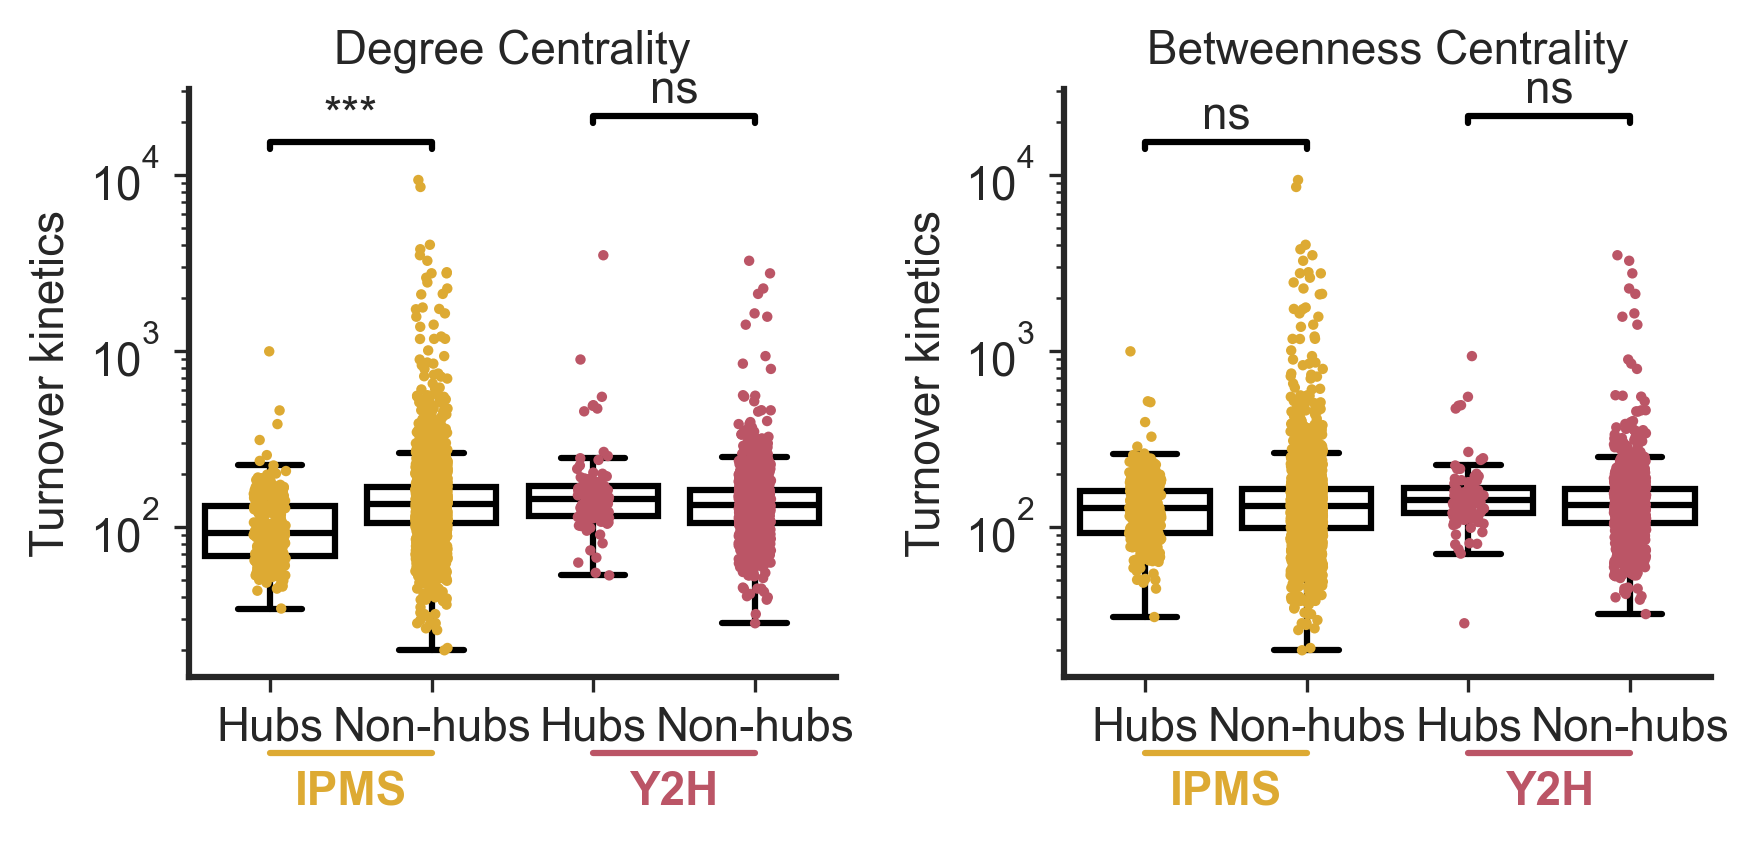

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import os

# Set global font settings for publication quality
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300

def test_hub_halflife_boxplot(selected_columns, ms_col, y2h_col, save_dir, metric_name, ax=None, save=True, show=True, print_stats=True):
    # === Define hub vs non-hub groups ===
    hubs_ms = selected_columns[selected_columns[ms_col] >= 90]['Villen_halflife_min'].dropna()
    nonhubs_ms = selected_columns[selected_columns[ms_col] < 90]['Villen_halflife_min'].dropna()
    hubs_y2h = selected_columns[selected_columns[y2h_col] >= 90]['Villen_halflife_min'].dropna()
    nonhubs_y2h = selected_columns[selected_columns[y2h_col] < 90]['Villen_halflife_min'].dropna()
    
    # === Combine into a single dataframe ===
    data = pd.DataFrame({
        'Group': (['Hubs MS'] * len(hubs_ms)) +
                 (['Non-hubs MS'] * len(nonhubs_ms)) +
                 (['Hubs Y2H'] * len(hubs_y2h)) +
                 (['Non-hubs Y2H'] * len(nonhubs_y2h)),
        't_half': np.concatenate([hubs_ms, nonhubs_ms, hubs_y2h, nonhubs_y2h])
    })
    
    # === Mann–Whitney tests (on log-transformed data for statistical test) ===
    if print_stats:
        print(f"\n=== Percentage Differences for {metric_name} ===")
        hubs_ms_median = np.median(hubs_ms)
        nonhubs_ms_median = np.median(nonhubs_ms)
        percentage_ms = ((hubs_ms_median - nonhubs_ms_median) / nonhubs_ms_median) * 100 if nonhubs_ms_median != 0 else 0
        print(f"Hubs MS are {percentage_ms:.2f}% greater than Non-hubs MS (medians: {hubs_ms_median:.2f} vs {nonhubs_ms_median:.2f})")
        
        hubs_y2h_median = np.median(hubs_y2h)
        nonhubs_y2h_median = np.median(nonhubs_y2h)
        percentage_y2h = ((hubs_y2h_median - nonhubs_y2h_median) / nonhubs_y2h_median) * 100 if nonhubs_y2h_median != 0 else 0
        print(f"Hubs Y2H are {percentage_y2h:.2f}% greater than Non-hubs Y2H (medians: {hubs_y2h_median:.2f} vs {nonhubs_y2h_median:.2f})")

        print(f"\n=== Mann–Whitney U Tests (log-transformed) for {metric_name} ===")
        def log_transform(series):
            return np.log10(series + 1) # Add 1 to avoid log(0)
        tests = [
            ('MS hubs vs MS non-hubs', log_transform(hubs_ms), log_transform(nonhubs_ms)),
            ('Y2H hubs vs Y2H non-hubs', log_transform(hubs_y2h), log_transform(nonhubs_y2h))
        ]
        p_values = []
        for name, g1, g2 in tests:
            stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
            print(f"{name}: U={stat:.2f}, p={p:.4g}, n1={len(g1)}, n2={len(g2)}")
            p_values.append(p)

        print(f"\n=== Kolmogorov-Smirnov Tests (log-transformed) for {metric_name} ===")
        for name, g1, g2 in tests:
            stat, p = ks_2samp(g1, g2)
            print(f"{name}: KS={stat:.2f}, p={p:.4g}, n1={len(g1)}, n2={len(g2)}")
    else:
        # Still compute p_values even if not printing
        def log_transform(series):
            return np.log10(series + 1)
        tests = [
            (log_transform(hubs_ms), log_transform(nonhubs_ms)),
            (log_transform(hubs_y2h), log_transform(nonhubs_y2h))
        ]
        p_values = [mannwhitneyu(g1, g2, alternative='two-sided')[1] for g1, g2 in tests]
    
    # === Create ax if not provided ===
    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(3, 3))
        ax = fig.add_subplot(111)
    
    # === Plot: swarm overlay + Boxplot ===
    sns.stripplot(
        data=data,
        x='Group',
        y='t_half', # Use original Villen_halflife_min data
        palette={'Hubs MS': '#DDAA33', 'Non-hubs MS': '#DDAA33',
                 'Hubs Y2H': '#BB5566', 'Non-hubs Y2H': '#BB5566'},
        size=2.5,
        alpha=1.0,
        jitter=True,
        ax=ax
    )
    sns.boxplot(
        data=data,
        x='Group',
        y='t_half', # Use original Villen_halflife_min data
        palette={'Hubs MS': '#DDAA33', 'Non-hubs MS': '#DDAA33',
                 'Hubs Y2H': '#BB5566', 'Non-hubs Y2H': '#BB5566'},
        showcaps=True,
        showfliers=False,
        fliersize=2,
        linewidth=1.5,
        boxprops={'edgecolor': 'black'},
        whiskerprops={'color': 'black', 'linewidth': 1.5},
        capprops={'color': 'black', 'linewidth': 1.5},
        medianprops={'color': 'black', 'linewidth': 1.5},
        width=0.8,
        ax=ax
    )
    for i, artist in enumerate(ax.patches):
        artist.set_facecolor('none')
        artist.set_edgecolor('black')
    
    # === Set y-axis to logarithmic scale ===
    ax.set_yscale('log')
    ax.set_ylabel('Turnover kinetics')
    ax.set_xlabel('')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['Hubs', 'Non-hubs', 'Hubs', 'Non-hubs'], rotation=0, ha='center')
    
    # === Add significance bars ===
    def add_significance_bar(x1, x2, y, p_value, ax, force_ns=False):
        height = y
        ax.plot([x1, x1, x2, x2], [height, height * 1.1, height * 1.1, height], lw=1.5, c='black')
        stars = 'ns' if force_ns or p_value >= 0.05 else '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*'
        ax.text((x1 + x2) * 0.5, height * 1.15, stars, ha='center', va='bottom', fontfamily='Arial', fontsize=11)
    
    max_y = data['t_half'].max()
    y_start = max_y * 1.5
    y_offset = 1.4
    comparisons = [(0, 1, 0), (2, 3, 1)]
    for idx, (x1, x2, test_idx) in enumerate(comparisons):
        force_ns = (test_idx == 1)
        add_significance_bar(x1, x2, y_start * (y_offset ** idx), p_values[test_idx], ax, force_ns=force_ns)
    
    # Add horizontal lines under MS and Y2H pairs
    ax.plot([0, 1], [-0.13, -0.13], color='#DDAA33', lw=1.5, clip_on=False, transform=ax.get_xaxis_transform())
    ax.plot([2, 3], [-0.13, -0.13], color='#BB5566', lw=1.5, clip_on=False, transform=ax.get_xaxis_transform())
    ax.text(0.5, -0.16, 'IPMS', ha='center', va='top', fontfamily='Arial', fontsize=11, transform=ax.get_xaxis_transform(), color='#DDAA33', fontweight='bold')
    ax.text(2.5, -0.16, 'Y2H', ha='center', va='top', fontfamily='Arial', fontsize=11, transform=ax.get_xaxis_transform(), color='#BB5566', fontweight='bold')
    
    ax.set_title(f'{metric_name}')
    sns.despine(ax=ax)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    
    # === Save + show ===
    if save:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, {
            'Degree Centrality': '2C-thalf-degree-centrality',
            'Betweenness Centrality': '2D-thalf-betweenness-centrality'
        }[metric_name] + '.svg')
        ax.get_figure().savefig(save_path, dpi=300, bbox_inches='tight')
    
    if standalone:
        if show:
            plt.show()
        else:
            plt.close(ax.get_figure())

# === Example: loop over both centrality metrics ===
save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE2"
metrics = [
    ('MS_degree_centrality_percentile', 'Y2H_degree_centrality_percentile', 'Degree Centrality'),
    ('MS_betweenness_centrality_percentile', 'Y2H_betweenness_centrality_percentile', 'Betweenness Centrality')
]

# Save individual plots (with stats printed)
for ms_col, y2h_col, metric_name in metrics:
    test_hub_halflife_boxplot(selected_columns, ms_col, y2h_col, save_dir, metric_name, ax=None, save=True, show=False, print_stats=True)

# Display adjacent plots (no additional prints)
fig, axs = plt.subplots(1, 2, figsize=(6, 3))
for i, (ms_col, y2h_col, metric_name) in enumerate(metrics):
    test_hub_halflife_boxplot(selected_columns, ms_col, y2h_col, save_dir, metric_name, ax=axs[i], save=False, show=False, print_stats=False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1880578/814788759.py:269: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2.0)


Fold-change (MS/Y2H), Percent Change, and KS test for each feature/centrality combination:
mean_molecules_per_cell vs Degree Centrality (all): Fold change = 1.04, Percent change = +4.2%, KS stat = 0.027, p = 0.4
mean_molecules_per_cell vs Degree Centrality (top10): Fold change = 2.28, Percent change = +128.5%, KS stat = 0.345, p = 6.9e-13
mean_molecules_per_cell vs Betweenness Centrality (all): Fold change = 1.04, Percent change = +4.2%, KS stat = 0.027, p = 0.4
mean_molecules_per_cell vs Betweenness Centrality (top10): Fold change = 2.35, Percent change = +135.0%, KS stat = 0.317, p = 5.4e-10
median_molecules_per_cell vs Degree Centrality (all): Fold change = 1.05, Percent change = +5.4%, KS stat = 0.027, p = 0.43
median_molecules_per_cell vs Degree Centrality (top10): Fold change = 2.43, Percent change = +143.0%, KS stat = 0.381, p = 1.2e-15
median_molecules_per_cell vs Betweenness Centrality (all): Fold change = 1.05, Percent change = +5.4%, KS stat = 0.027, p = 0.43
median_molecule

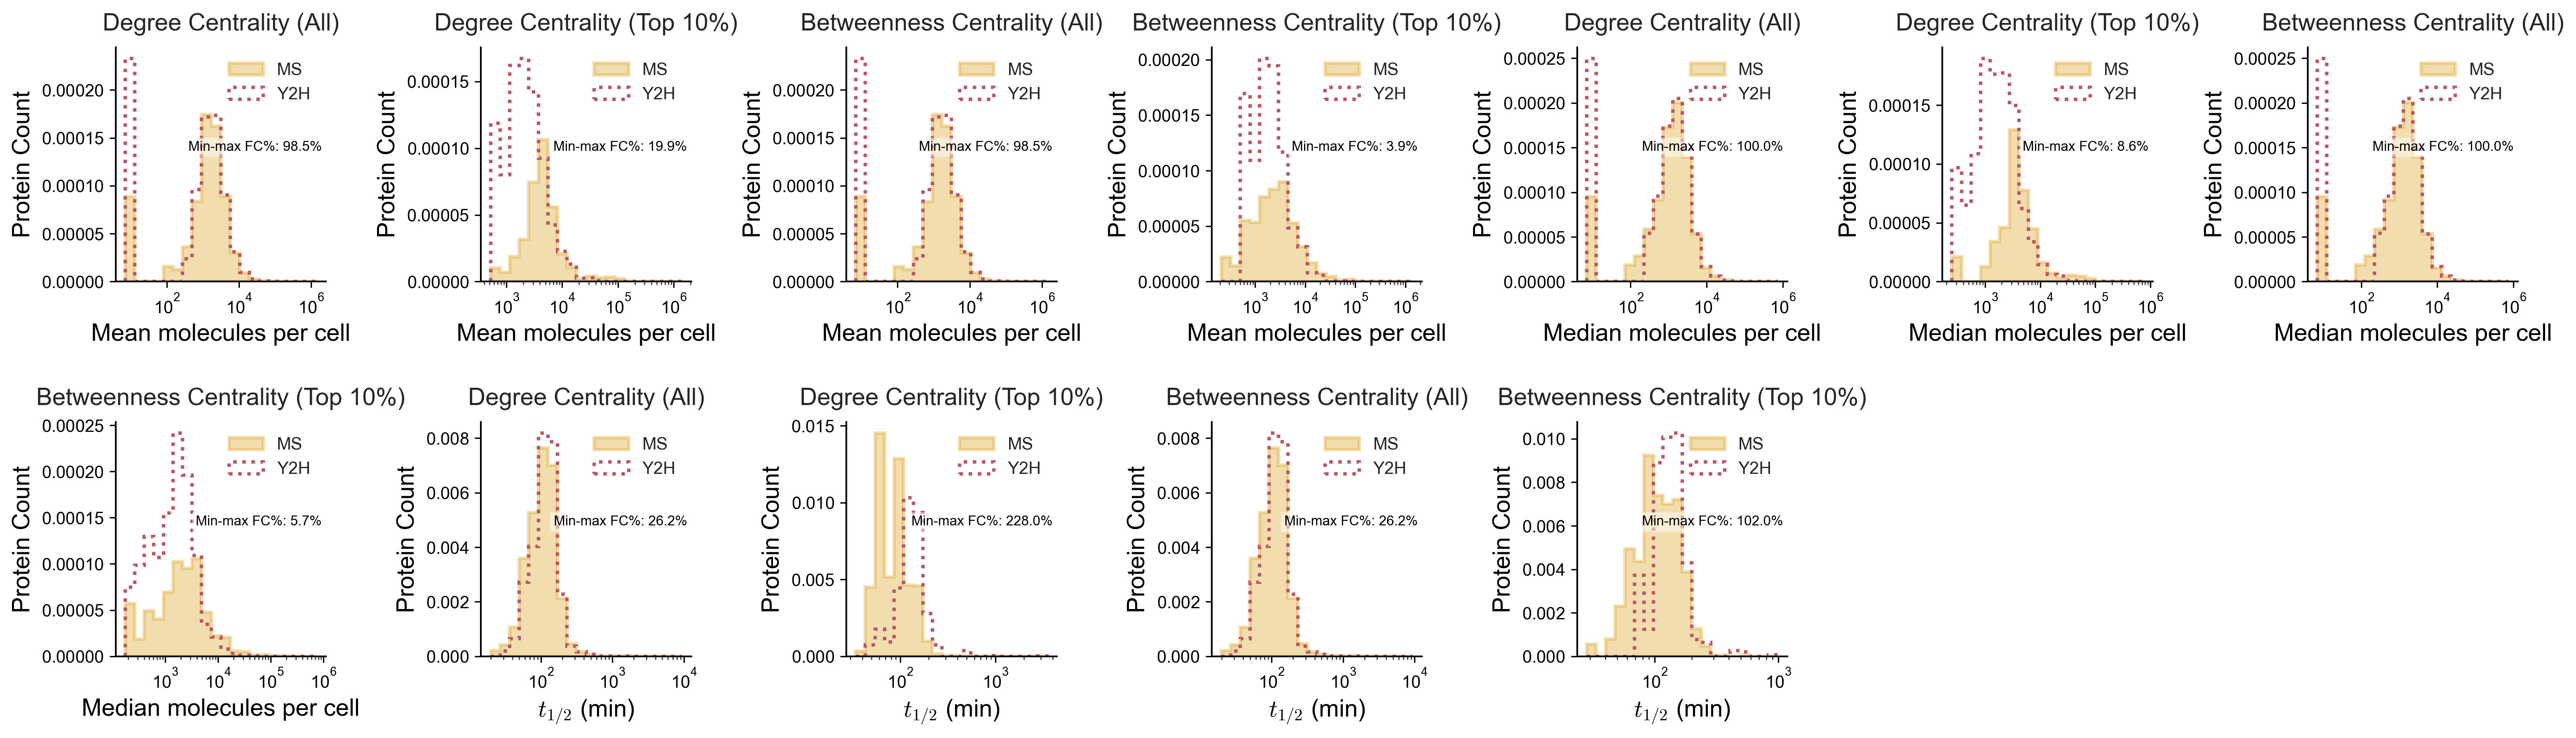

In [63]:
# === 1. IMPORT LIBRARIES AND SET GLOBAL PLOT STYLE ===
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
import os
import scipy.stats as stats  

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
sns.set_style('ticks')

# === 2. DEFINE OUTPUT DIRECTORY ===
save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025"
os.makedirs(save_dir, exist_ok=True)

# === 3. DEFINE FEATURES, LABELS, CENTRALITY PAIRS, COLORS, CUT-OFF ===
features = ['mean_molecules_per_cell', 'median_molecules_per_cell', 'Villen_halflife_min']
x_labels_mathtext = [
    r"Mean molecules per cell",
    r"Median molecules per cell",
    r"$t_{1/2}$ (min)"
]
centrality_metrics = [
    ('MS_degree_centrality_percentile', 'Y2H_degree_centrality_percentile', 'Degree Centrality'),
    ('MS_betweenness_centrality_percentile', 'Y2H_betweenness_centrality_percentile', 'Betweenness Centrality'),
]
centrality_modes = ['all', 'top10'] 
centrality_cutoff = 90
# Expand centrality_metrics by mode (all, top10)
centrality_pairs = []
for metric in centrality_metrics:
    for mode in centrality_modes:
        centrality_pairs.append(metric + (mode,))
ms_color = "#DDAA33"
y2h_color = "#BB5566"

# === 4. SET PLOT PANEL LAYOUT ===
n_panels = 42
ncols = 7
nrows = 6
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 3*nrows), sharey=False, constrained_layout=True)
axes = axes.flatten()

# === 5. PLOTTING & STATISTICS LOOP ===
fold_changes = [] 

panel_idx = 0
n_bins = 20  # Decrease number of bins for wider bars

for fidx, feature in enumerate(features):
    x_label = x_labels_mathtext[fidx]
    for pair in centrality_pairs:
        if panel_idx >= len(axes):
            break
        ms_col, y2h_col, centrality_name, mode = pair
        ax = axes[panel_idx]

        # === Check columns exist ===
        missing_cols = [col for col in [ms_col, y2h_col, feature] if col not in selected_columns.columns]
        if missing_cols:
            print(f"WARNING: Missing columns {missing_cols} in selected_columns. Skipping panel {centrality_name} {feature} ({mode}).")
            ax.axis('off')
            panel_idx += 1
            continue

        # === Select all or top 10% based on mode ===
        if mode == 'top10':
            ms_mask = selected_columns[ms_col] >= centrality_cutoff
            y2h_mask = selected_columns[y2h_col] >= centrality_cutoff
        elif mode == 'all':
            ms_mask = selected_columns[ms_col].notna()
            y2h_mask = selected_columns[y2h_col].notna()
        else:
            print(f"WARNING: Unknown mode {mode} for {centrality_name} {feature}. Skipping.")
            ax.axis('off')
            panel_idx += 1
            continue

        ms_values = pd.to_numeric(selected_columns.loc[ms_mask, feature], errors='coerce').dropna()
        y2h_values = pd.to_numeric(selected_columns.loc[y2h_mask, feature], errors='coerce').dropna()

        # --- KS Test ---
        if len(ms_values) > 5 and len(y2h_values) > 5:
            ks_stat, ks_pval = ks_2samp(ms_values, y2h_values)
        else:
            ks_stat, ks_pval = np.nan, np.nan

        ms_min = ms_values.min() if len(ms_values) > 0 else np.nan
        ms_max = ms_values.max() if len(ms_values) > 0 else np.nan
        y2h_min = y2h_values.min() if len(y2h_values) > 0 else np.nan
        y2h_max = y2h_values.max() if len(y2h_values) > 0 else np.nan
        fc_ms = ms_max / ms_min if ms_min not in [0, np.nan] and ms_min != 0 else np.nan
        fc_y2h = y2h_max / y2h_min if y2h_min not in [0, np.nan] and y2h_min != 0 else np.nan
        ms_median = np.nanmedian(ms_values) if len(ms_values) > 0 else np.nan
        y2h_median = np.nanmedian(y2h_values) if len(y2h_values) > 0 else np.nan
        fold_change = ms_median / y2h_median if y2h_median not in [0, np.nan] else np.nan
        percent_change = 100 * (ms_median - y2h_median) / y2h_median if y2h_median not in [0, np.nan] else np.nan

        fold_changes.append((f"{feature} vs {centrality_name} ({mode})", fold_change, percent_change, ks_stat, ks_pval))

        # === Plot histogram + density for MS ===
        plotted = False
        if len(ms_values) > 5 and len(y2h_values) > 5:
            min_edge = min(ms_values.min(), y2h_values.min())
            max_edge = max(ms_values.max(), y2h_values.max())
            bins = np.logspace(np.log10(min_edge), np.log10(max_edge), n_bins + 1)
        else:
            valid_vals = ms_values if len(ms_values) > 5 else y2h_values
            min_edge = valid_vals.min()
            max_edge = valid_vals.max()
            bins = np.logspace(np.log10(min_edge), np.log10(max_edge), n_bins + 1)

        if len(ms_values) > 5:
            ax.hist(
                ms_values, 
                bins=bins, 
                color=ms_color, 
                linewidth=2, 
                label='MS', 
                density=True, 
                histtype='stepfilled', 
                alpha=0.4, 
                edgecolor=ms_color
            )
            plotted = True
        if len(y2h_values) > 5:
            ax.hist(
                y2h_values,
                bins=bins,
                histtype='step',
                color=y2h_color,
                linewidth=2,
                label='Y2H',
                density=True,
                linestyle='dotted'
            )
            plotted = True
        ax.set_xscale('log')

        if plotted and ms_min not in [0, np.nan] and y2h_min not in [0, np.nan] and not np.isnan(fc_y2h) and not np.isnan(fc_ms) and fc_ms != 0:
            fold_change_percent = (fc_y2h / fc_ms) * 100
            ax.text(
                0.98, 0.60,
                f"Min-max FC%: {fold_change_percent:.1f}%",
                transform=ax.transAxes,
                fontsize=8, color='black',
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=2.0)
            )    

        # === Set title and labels, style axes, legend etc as before ===
        mode_label = " (Top 10%)" if mode == "top10" else " (All)"
        ax.set_title(f"{centrality_name}{mode_label}", pad=10)
        ax.set_xlabel(x_label, color='black')
        ax.set_ylabel("Protein Count", color='black')
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.spines['left'].set_position(('axes', 0))
        ax.spines['bottom'].set_position(('zero'))
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_linewidth(1)
        ax.spines['bottom'].set_linewidth(1)
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_ticks_position('left')
        ax.tick_params(axis='both', which='major', labelsize=10, colors='black')
        if plotted:
            ax.legend(frameon=False, fontsize=10, loc='upper right')
        ax.grid(False)
        panel_idx += 1
           
        
# === 6. Saving Individual Plots ===
#plot_idx = 1
#for fidx, feature in enumerate(features):
    #x_label = x_labels_mathtext[fidx]
    #for pair in centrality_pairs:
        #ms_col, y2h_col, centrality_name, mode = pair

        # (Repeat: Check for missing cols, create masks as in Block 5)
        #if any(col not in selected_columns.columns for col in [ms_col, y2h_col, feature]):
        #    continue
        #if mode == 'top10':
        #   ms_mask = selected_columns[ms_col] >= centrality_cutoff
        #    y2h_mask = selected_columns[y2h_col] >= centrality_cutoff
        #else:
        #   ms_mask = selected_columns[ms_col].notna()
        #    y2h_mask = selected_columns[y2h_col].notna()
        #ms_values = pd.to_numeric(selected_columns.loc[ms_mask, feature], errors='coerce').dropna()
        #y2h_values = pd.to_numeric(selected_columns.loc[y2h_mask, feature], errors='coerce').dropna()
        
        # Before plotting histograms, define shared bins using both ms_values and y2h_values
        #if len(ms_values) > 5 and len(y2h_values) > 5:
        #    min_edge = min(ms_values.min(), y2h_values.min())
        #    max_edge = max(ms_values.max(), y2h_values.max())
        #    bins = np.logspace(np.log10(min_edge), np.log10(max_edge), n_bins + 1)
        #else:
        #    # If only one has data, define bins from that one
        #    valid_vals = ms_values if len(ms_values) > 5 else y2h_values
        #    min_edge = valid_vals.min()
        #    max_edge = valid_vals.max()
        #    bins = np.logspace(np.log10(min_edge), np.log10(max_edge), n_bins + 1)

        #fig_indiv, ax_indiv = plt.subplots(figsize=(4, 3))
        #plotted = False
        #if len(ms_values) > 5 and len(y2h_values) > 5:
        #    min_edge = min(ms_values.min(), y2h_values.min())
        #    max_edge = max(ms_values.max(), y2h_values.max())
        #    bins = np.logspace(np.log10(min_edge), np.log10(max_edge), n_bins + 1)
        #else:
        #    valid_vals = ms_values if len(ms_values) > 5 else y2h_values
        #    min_edge = valid_vals.min()
        #    max_edge = valid_vals.max()
        #    bins = np.logspace(np.log10(min_edge), np.log10(max_edge), n_bins + 1)

        #if len(ms_values) > 5:
        #    ax_indiv.hist(ms_values, bins=bins, color=ms_color, linewidth=2, label='MS', density=True, histtype='stepfilled', alpha=0.4, edgecolor=ms_color)
        #    plotted = True
        #if len(y2h_values) > 5:
        #    ax_indiv.hist(y2h_values, bins=bins, histtype='step', color=y2h_color, linewidth=2, label='Y2H', density=True, linestyle='dotted')
        #    plotted = True
            
        #ax_indiv.set_xscale('log')
         
        #mode_label = " (Top 10%)" if mode == "top10" else " (All)"
        #ax_indiv.set_title(f"{centrality_name}{mode_label}", pad=10)
        #ax_indiv.set_xlabel(x_label, color='black')
        #ax_indiv.set_ylabel("Protein Count", color='black')

        # Clean spines, legend, etc. (repeat Block 5)
        #for spine in ax_indiv.spines.values():
        #    spine.set_visible(False)
        #ax_indiv.spines['left'].set_visible(True)
        #ax_indiv.spines['bottom'].set_visible(True)
        #ax_indiv.spines['left'].set_color('black')
        #ax_indiv.spines['bottom'].set_color('black')
        #ax_indiv.spines['left'].set_linewidth(1)
        #ax_indiv.spines['bottom'].set_linewidth(1)
        #ax_indiv.xaxis.set_ticks_position('bottom')
        #ax_indiv.yaxis.set_ticks_position('left')
        #ax_indiv.tick_params(axis='both', which='major', labelsize=10, colors='black')
        #if plotted:
        #    ax_indiv.legend(frameon=False, fontsize=10, loc='upper right')
        #ax_indiv.grid(False)

        # Save with your filename format:
        #safe_feature = feature.replace('/', '_').replace('\\', '_').replace(' ', '_')
        #safe_centrality = centrality_name.replace('/', '_').replace('\\', '_').replace(' ', '_')
        #filename = f"1D{plot_idx}_{safe_feature}_on_{safe_centrality}_on_Density.png"
        #fig_indiv.savefig(os.path.join(save_dir, filename), dpi=600, bbox_inches='tight')
        #plt.close(fig_indiv)
        #plot_idx += 1

# === 7. REMOVE UNUSED SUBPLOTS AND FINALIZE PANEL ===
for j in range(panel_idx, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout(pad=2.0)

# === 8. SAVE FIGURE AS HIGH-RES PNG ===
#fig.savefig(os.path.join(save_dir, "Top10_Centrality_Feature_Distributions.png"), dpi=600, bbox_inches='tight')
#plt.show()

# === 9. PRINT FOLD-CHANGE SUMMARY ===
print("Fold-change (MS/Y2H), Percent Change, and KS test for each feature/centrality combination:")
for desc, fc, pc, ks_stat, ks_pval in fold_changes:
    print(f"{desc}: Fold change = {fc:.2f}, Percent change = {pc:+.1f}%, KS stat = {ks_stat:.3f}, p = {ks_pval:.2g}")